<a href="https://colab.research.google.com/github/elviraasch/Analisis-dan-Visualisasi-Data/blob/main/PENGANTAR_UTS_AVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
df = pd.read_csv('Company_data.csv')
print(df.head())


      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [ ]:
import pandas as pd

# Load data
df_company = pd.read_csv('Company_data.csv')

# Menampilkan ringkasan statistik deskriptif data
print(df_company.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


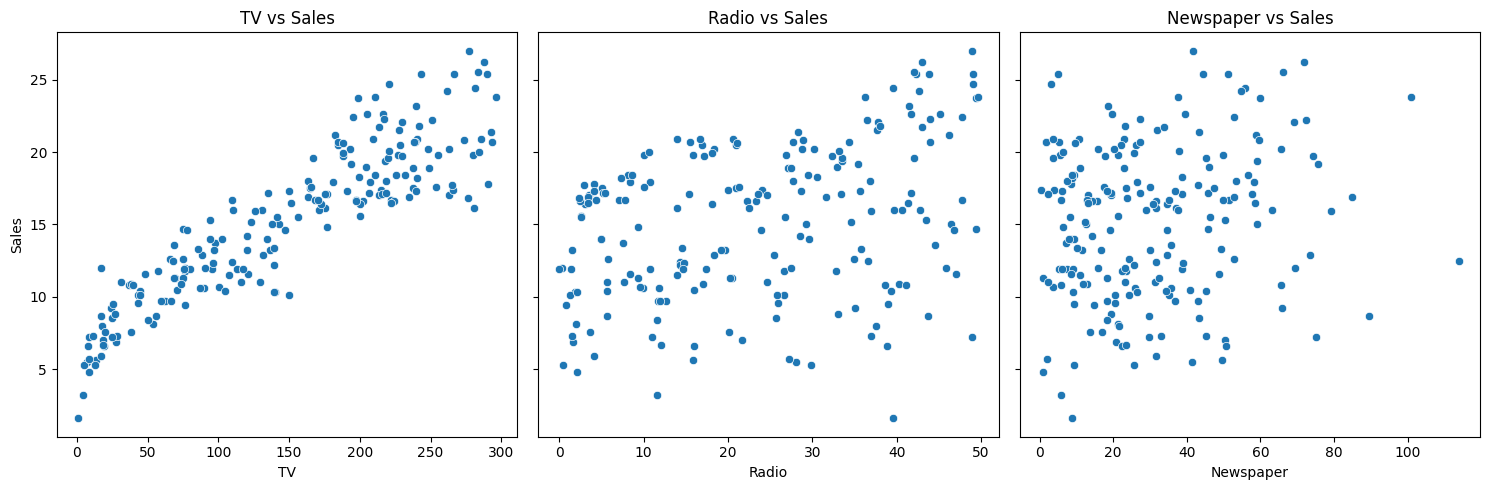

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Scatter plot TV vs Sales
sns.scatterplot(data=df_company, x='TV', y='Sales', ax=axes[0])
axes[0].set_title('TV vs Sales')

# Scatter plot Radio vs Sales
sns.scatterplot(data=df_company, x='Radio', y='Sales', ax=axes[1])
axes[1].set_title('Radio vs Sales')

# Scatter plot Newspaper vs Sales
sns.scatterplot(data=df_company, x='Newspaper', y='Sales', ax=axes[2])
axes[2].set_title('Newspaper vs Sales')

plt.tight_layout()
plt.show()

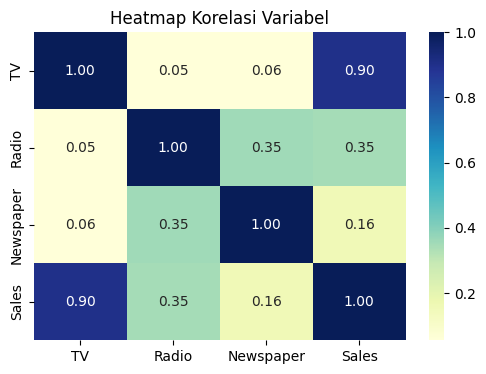

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_company.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Heatmap Korelasi Variabel')
plt.show()

/tmp/ipykernel_23799/1351890818.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a_train = model_train.params[0]
/tmp/ipykernel_23799/1351890818.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b_train = model_train.params[1]


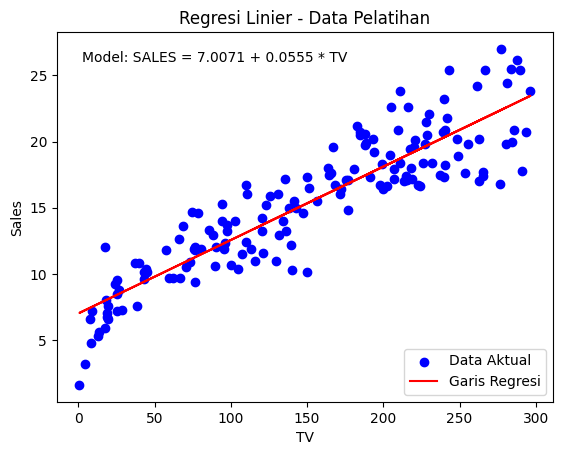

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Memisahkan variabel independen (X) dan dependen (y)
X = df_company['TV']
y = df_company['Sales']

# Splitting data (misal 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menambahkan konstanta untuk model OLS statsmodels
X_train_ols = sm.add_constant(X_train)
model_train = sm.OLS(y_train, X_train_ols).fit()

# Mengambil nilai intersep (a) dan koefisien (b)
a_train = model_train.params[0]
b_train = model_train.params[1]
teks_model = f"Model: SALES = {a_train:.4f} + {b_train:.4f} * TV"
plt.text(0.05, 0.95, teks_model, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# Plot Data Pelatihan dan Garis Regresi
plt.scatter(X_train, y_train, color='blue', label='Data Aktual')
plt.plot(X_train, model_train.predict(X_train_ols), color='red', label='Garis Regresi')

plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('Regresi Linier - Data Pelatihan')
plt.legend()
plt.show()

/tmp/ipykernel_23799/2172142766.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a_train = model_train.params[0]
/tmp/ipykernel_23799/2172142766.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b_train = model_train.params[1]


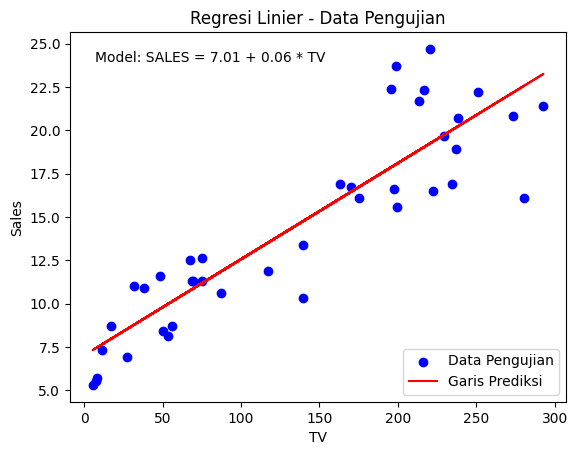

In [ ]:
X_test_ols = sm.add_constant(X_test)

# Plot Data Pengujian dan Garis Regresi
plt.scatter(X_test, y_test, color='blue', label='Data Pengujian')
plt.plot(X_test, model_train.predict(X_test_ols), color='red', label='Garis Prediksi')

a_train = model_train.params[0]
b_train = model_train.params[1]
teks_model = f"Model: SALES = {a_train:.2f} + {b_train:.2f} * TV"
plt.text(0.05, 0.95, teks_model, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('Regresi Linier - Data Pengujian')
plt.legend()
plt.show()

In [ ]:
r2_train = model_train.rsquared

y_pred_test = model_train.predict(X_test_ols)
import numpy as np
r2_test = np.corrcoef(y_test, y_pred_test)[0, 1]**2

print(f"R-squared Data Pelatihan: {r2_train:.4f}")
print(f"R-squared Data Pengujian: {r2_test:.4f}")

R-squared Data Pelatihan: 0.8135
R-squared Data Pengujian: 0.8036


In [9]:
import pandas as pd
cpns = pd.read_csv('testcpns.csv')
print(cpns.describe())

            toefl        ipk  pengalaman_kerja   diterima
count   40.000000  40.000000         40.000000  40.000000
mean   654.000000   2.694500          3.425000   0.475000
std     61.427464   0.653899          1.737778   0.505736
min    540.000000   1.070000          1.000000   0.000000
25%    607.500000   2.070000          2.000000   0.000000
50%    660.000000   3.030000          4.000000   0.000000
75%    690.000000   3.070000          5.000000   1.000000
max    780.000000   4.000000          6.000000   1.000000


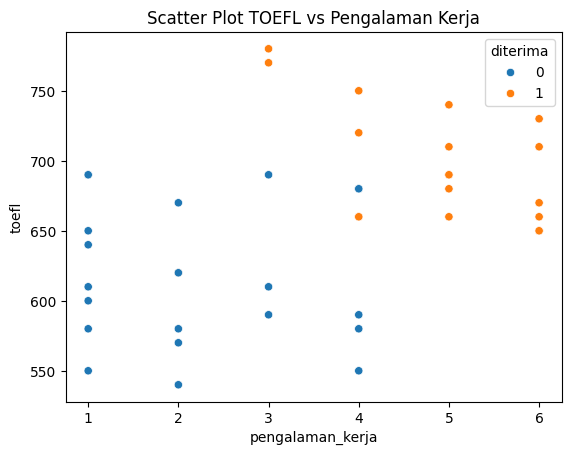

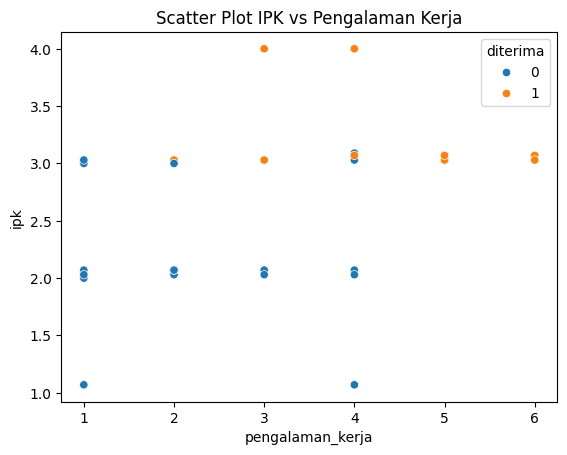

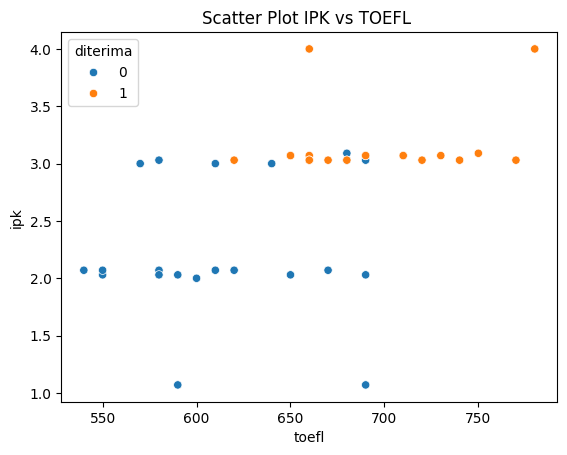

In [ ]:
sns.scatterplot(data=df_cpns, x='pengalaman_kerja', y='toefl', hue='diterima')
plt.title('Scatter Plot TOEFL vs Pengalaman Kerja')
plt.show()

sns.scatterplot(data=df_cpns, x='pengalaman_kerja', y='ipk', hue='diterima')
plt.title('Scatter Plot IPK vs Pengalaman Kerja')
plt.show()

sns.scatterplot(data=df_cpns, x='toefl', y='ipk', hue='diterima')
plt.title('Scatter Plot IPK vs TOEFL ')
plt.show()

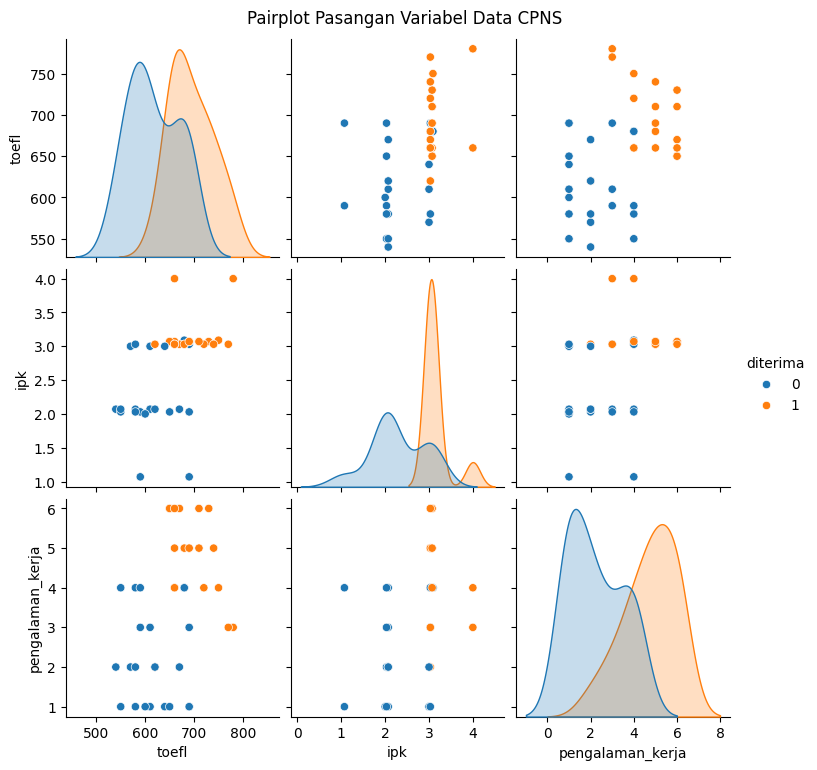

In [ ]:
sns.pairplot(df_cpns, hue='diterima', vars=['toefl', 'ipk', 'pengalaman_kerja'])
plt.suptitle('Pairplot Pasangan Variabel Data CPNS', y=1.02)
plt.show()

In [ ]:
X_log = df_cpns[['toefl', 'ipk', 'pengalaman_kerja']]
y_log = df_cpns['diterima']

log_reg = LogisticRegression()
log_reg.fit(X_log, y_log)

y_pred_log = log_reg.predict(X_log)

cm = confusion_matrix(y_log, y_pred_log)
print("Confusion Matrix yang diperoleh:")
print(cm)

Confusion Matrix yang diperoleh:
[[18  3]
 [ 1 18]]


--- OUTPUT TEXT CONFUSION MATRIX ---
[[18  3]
 [ 1 18]]


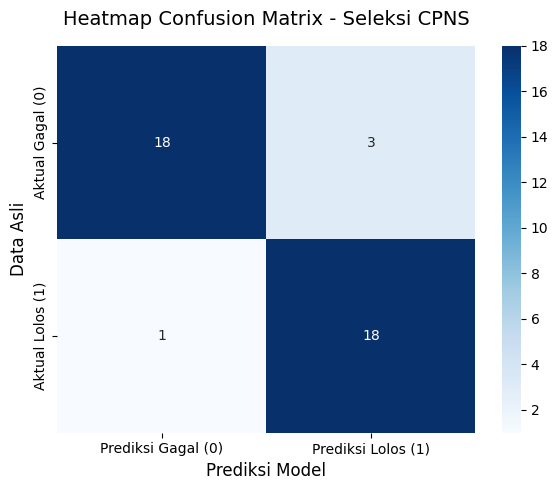

In [ ]:
X_log = df_cpns[['toefl', 'ipk', 'pengalaman_kerja']]
y_log = df_cpns['diterima']

log_reg = LogisticRegression()
log_reg.fit(X_log, y_log)

# Mendapatkan hasil prediksi model
y_pred_log = log_reg.predict(X_log)

cm = confusion_matrix(y_log, y_pred_log)
print("--- OUTPUT TEXT CONFUSION MATRIX ---")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Prediksi Gagal (0)', 'Prediksi Lolos (1)'],
            yticklabels=['Aktual Gagal (0)', 'Aktual Lolos (1)'])

plt.title('Heatmap Confusion Matrix - Seleksi CPNS', fontsize=14, pad=15)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Data Asli', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
df_analisis = df_cpns.copy()
df_analisis['Prediksi_Diterima'] = y_pred_log

print(df_analisis[['toefl', 'ipk', 'pengalaman_kerja', 'diterima', 'Prediksi_Diterima']].head(40))

    toefl   ipk  pengalaman_kerja  diterima  Prediksi_Diterima
0     780  4.00                 3         1                  1
1     750  3.09                 4         1                  1
2     690  3.03                 3         0                  1
3     710  3.07                 5         1                  1
4     680  3.09                 4         0                  1
5     730  3.07                 6         1                  1
6     690  2.03                 1         0                  0
7     720  3.03                 4         1                  1
8     740  3.03                 5         1                  1
9     690  1.07                 1         0                  0
10    610  2.07                 3         0                  0
11    690  3.07                 5         1                  1
12    710  3.07                 6         1                  1
13    680  3.03                 4         0                  1
14    770  3.03                 3         1            

In [ ]:
df_baru = pd.DataFrame({
    'toefl': [590, 740, 680, 610, 710],
    'ipk': [2.0, 3.7, 3.3, 2.3, 3.0],
    'pengalaman_kerja': [3, 4, 6, 1, 5]
})

prediksi_baru = log_reg.predict(df_baru)

df_baru['Status_Prediksi'] = ['Diterima' if p == 1 else 'Tidak Diterima' for p in prediksi_baru]

print("Hasil Prediksi Kelulusan Pelamar Baru:")
print(df_baru)

Hasil Prediksi Kelulusan Pelamar Baru:
   toefl  ipk  pengalaman_kerja Status_Prediksi
0    590  2.0                 3  Tidak Diterima
1    740  3.7                 4        Diterima
2    680  3.3                 6        Diterima
3    610  2.3                 1  Tidak Diterima
4    710  3.0                 5        Diterima


In [1]:
sns.pairplot(df,hue =
’surv_status’, height= 3)
plt.show()

SyntaxError: invalid character '’' (U+2019) (883836097.py, line 2)